# TakaPay Social Data — Deep-Dive Findings Notebook

**Dataset:** `data/takapay_sample_data.csv` — 660 social posts about a fictional mobile wallet (TakaPay), June 2026.
**Purpose:** every finding, reproduced from raw data, in the order the story unfolds. Run top-to-bottom (`Kernel → Restart & Run All`). Only needs `pandas` + `matplotlib`.

## The story in one paragraph

The dataset looks clean (no nulls, no bad dates) but hides **two planted traps**: (1) 70 rows (10.6%) are not about the brand at all, and (2) **34 rows carry sentiment labels *and* scores that contradict their own text** — asymmetrically, in the brand's favor. A naive dashboard reads 51.2% negative; filtering irrelevant rows moves it to 55.8%; auditing the labels shows the truth is ~58%. The raw feed understates the brand's problem by ~7 points. Beyond the traps: one topic (`failed_transaction`) drives a third of all conversation at ~90% negativity, the competitor signal (NgoodPay) is clean and 100% negative, the "Banglish is angrier" pattern is a total confound, and the engagement columns are pure noise.

| # | Finding | Section |
|---|---|---|
| 1 | `brand_mention` flag carries zero information; 70 rows never mention the brand | §2 |
| 2 | Relevance filtering shifts sentiment 51.2% → 55.8% negative | §3 |
| 3 | Label/score "boundary overlap" is 100% an off-topic artifact (report §3 correction) | §4 |
| 4 | 68% of the dataset is templated text | §5 |
| 5 | **34 rows have flipped sentiment (label+score vs text) — the big trap** | §6 |
| 6 | The trust arc: 51.2 → 55.8 → ~58% negative | §7 |
| 7 | `failed_transaction` = 33% of volume at ~90% negative | §8 |
| 8 | "Fix this first": priority ranking, competitor routed separately | §9 |
| 9 | NgoodPay: 72 comparison posts, 100% negative + 9-post CI signal | §10 |
| 10 | Language ⊥ topic: the "Banglish is harsher" claim is a confound | §11 |
| 11 | Platform explains volume, not sentiment | §12 |
| 12 | 10 exact-duplicate pairs across different authors/platforms | §13 |
| 13 | Engagement columns are uniform noise | §14 |
| 14 | Daily volume is flat — no time-series story exists | §15 |


## 1. Setup & first look

Palette note: sentiment uses fixed *status* colors (negative red, neutral gray, positive green) everywhere in this notebook — color follows the entity, never position. Magnitude bars use a single blue.

In [1]:
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# fixed color roles — used consistently in every chart
SENT = {"negative": "#e34948", "neutral": "#8a8983", "positive": "#008300"}
SENT_ORDER = ["negative", "neutral", "positive"]
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

def style(ax, xgrid=False, ygrid=True):
    ax.grid(axis="x" if xgrid else "y", color=GRID, lw=0.7, zorder=0)
    ax.set_axisbelow(True)

df = pd.read_csv("data/takapay_sample_data.csv", dtype={"id": str})
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"rows={len(df)}  cols={list(df.columns)}")
print(f"dates: {df.timestamp.min()} → {df.timestamp.max()}")
print(f"nulls: {int(df.isna().sum().sum())}")
df.head(3)

rows=660  cols=['id', 'platform', 'timestamp', 'author', 'text', 'language', 'brand_mention', 'sentiment', 'sentiment_score', 'topic', 'reactions', 'comments']
dates: 2026-06-01 01:26:00 → 2026-06-30 23:50:00
nulls: 0


,id,platform,timestamp,author,text,language,brand_mention,sentiment,sentiment_score,topic,reactions,comments
0,1017,TikTok,2026-06-21 01:16:00,Farhana15,"TakaPay helpline e 30 min wait korlam, keu dho...",bn-en,True,negative,8,customer_care,174,76
1,1173,TikTok,2026-06-08 23:49:00,Sabbir77,Paid my gas bill on TakaPay in under a minute....,en,True,positive,88,bill_payment,40,106
2,1043,YouTube,2026-06-25 04:05:00,Tuhin27,Paid my internet bill on TakaPay in under a mi...,en,True,positive,92,bill_payment,148,57


In [2]:
# the surface-level shape of the feed
print("platforms:", df.platform.value_counts().to_dict(), "\n")
print("languages:", df.language.value_counts().to_dict(), "\n")
print("sentiment (raw):", df.sentiment.value_counts().to_dict(), "\n")
print("topics:")
print(df.topic.value_counts().to_string())

platforms: {'Facebook': 225, 'Reddit': 81, 'News/Media': 76, 'Instagram': 74, 'YouTube': 72, 'TikTok': 68, 'Twitter': 64} 

languages: {'bn-en': 390, 'bn': 155, 'en': 115} 

sentiment (raw): {'negative': 338, 'positive': 237, 'neutral': 85} 

topics:
topic
failed_transaction    220
competitor             81
cashback_offer         63
off_topic              61
recharge               50
send_money             50
charges_fees           30
agent_network          26
bill_payment           24
feature_query          19
customer_care          13
login_otp              10
app_crash               9
app_experience          2
product_news            2


**Reading this:** no missing values, tidy dtypes, plausible categories. The dataset *looks* clean — which is exactly why the traps below are dangerous: nothing here fails a standard data-quality check.

## 2. Finding 1 — the `brand_mention` flag is dead weight, and 10.6% of rows aren't about the brand

Every single row says `brand_mention = True`. A flag with one value filters nothing. The real test is embarrassingly simple: **does the text contain "TakaPay"?**

In [3]:
print("brand_mention values:", df.brand_mention.value_counts().to_dict())

df["mentions_brand"] = df.text.str.lower().str.contains("takapay")
no_brand = df[~df.mentions_brand]
print(f"\nrows whose text NEVER mentions TakaPay: {len(no_brand)} ({len(no_brand)/len(df):.1%})")
print("\nby topic:", no_brand.topic.value_counts().to_dict())
print("their sentiment:", no_brand.sentiment.value_counts().to_dict())

brand_mention values: {True: 660}

rows whose text NEVER mentions TakaPay: 70 (10.6%)

by topic: {'off_topic': 61, 'competitor': 9}
their sentiment: {'neutral': 38, 'positive': 23, 'negative': 9}


In [4]:
# the two species of non-brand rows
print("--- 61 off_topic rows = pure scrape noise (traffic, weather, food, football):")
for t in no_brand[no_brand.topic == "off_topic"].text.sample(5, random_state=1):
    print("  •", t)
print("\n--- 9 competitor rows = NgoodPay promo chatter (a REAL market signal, wrong bucket):")
for t in no_brand[no_brand.topic == "competitor"].text.head(3):
    print("  •", t)

--- 61 off_topic rows = pure scrape noise (traffic, weather, food, football):
  • Ei Motijheel er biryani ta must try, khub valo.
  • Traffic ajke Motijheel e insane, 2 ghonta laglo pouchte.
  • Ei Farmgate er biryani ta must try, khub valo.
  • Notun phone kinbo vabtesi, keu Banglalink er offer jano?
  • Ajke Rajshahi te prochur bristi, office jete 30 min deri hoye gelo.

--- 9 competitor rows = NgoodPay promo chatter (a REAL market signal, wrong bucket):
  • NgoodPay notun 500 taka cashback offer diyeche, keu try koreche?
  • NgoodPay notun 2000 taka cashback offer diyeche, keu try koreche?
  • NgoodPay notun 1000 taka cashback offer diyeche, keu try koreche?


**Judgment:** these 70 rows are two different problems.
- The **61 `off_topic` rows** are noise a broad keyword scrape swept in. They are 0% negative (38 neutral + 23 positive), so leaving them in *inflates the brand's apparent positivity*.
- The **9 competitor-only rows** are organic chatter about NgoodPay's cashback promos — not noise, but not TakaPay sentiment either. **Ruling: excluded from brand sentiment, tracked as a separate competitive-intelligence signal** (they all follow one template: *"NgoodPay notun X taka cashback offer diyeche"*).

Everything brand-related below is computed on the 590 **Relevant Mentions**.

## 3. Finding 2 — filtering the noise changes the story: 51.2% → 55.8% negative

           raw (n=660)  clean (n=590)
sentiment                            
negative          51.2           55.8
neutral           12.9            8.0
positive          35.9           36.3


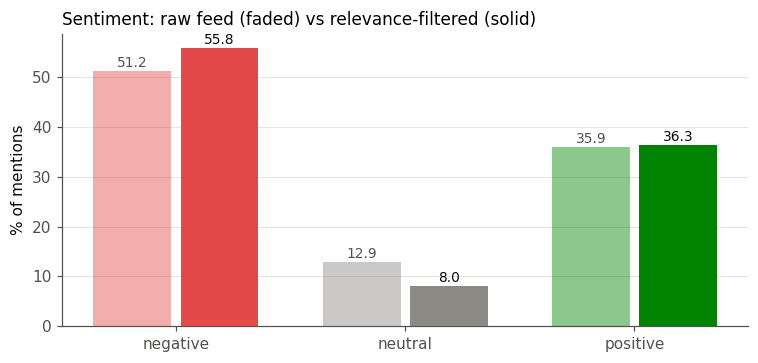

In [5]:
clean = df[df.mentions_brand].copy()

def sent_pct(frame):
    return (frame.sentiment.value_counts(normalize=True) * 100).reindex(SENT_ORDER)

comp_tbl = pd.DataFrame({"raw (n=660)": sent_pct(df), "clean (n=590)": sent_pct(clean)}).round(1)
print(comp_tbl)

fig, ax = plt.subplots(figsize=(7, 3.4))
x = range(3)
for i, (col, off) in enumerate([("raw (n=660)", -0.19), ("clean (n=590)", 0.19)]):
    vals = comp_tbl[col]
    bars = ax.bar([p + off for p in x], vals, width=0.34, zorder=3,
                  color=[SENT[s] for s in SENT_ORDER], alpha=1 if i else 0.45)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=9,
                color=INK if i else MUTED)
ax.set_xticks(list(x)); ax.set_xticklabels(SENT_ORDER)
ax.set_ylabel("% of mentions"); style(ax)
ax.set_title("Sentiment: raw feed (faded) vs relevance-filtered (solid)", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

**Judgment:** the filter doesn't just shrink n — it moves negative sentiment up **4.6 points** and cuts neutral by 5. A brand manager trusting the raw number gets a picture that is too rosy. This is why "what reaches the dashboard" matters more than "what the dashboard looks like".

## 4. Finding 3 — the label/score "inconsistency" is entirely an off-topic artifact

First-pass analysis (and an earlier draft of the report) claimed the sentiment *label* and *score* disagree at the boundary: 20 rows labeled `positive` score 46–59, inside the neutral band. True — **but every single one of those 20 rows is `off_topic` noise.** After relevance filtering, labels partition the score axis perfectly.

In [6]:
low_pos = df[(df.sentiment == "positive") & (df.sentiment_score < 60)]
print(f"positive-labeled rows scoring <60: {len(low_pos)}  → topics: {low_pos.topic.value_counts().to_dict()}")

def ranges(frame, name):
    g = frame.groupby("sentiment").sentiment_score.agg(["min", "max", "count"]).reindex(SENT_ORDER)
    print(f"\n{name}:\n{g}")

ranges(df, "RAW — positive dips to 46, inside the neutral 45–60 band")
ranges(clean, "CLEAN — perfect partition: 6–30 | 45–60 | 72–94, zero overlap")

positive-labeled rows scoring <60: 20  → topics: {'off_topic': 20}

RAW — positive dips to 46, inside the neutral 45–60 band:
           min  max  count
sentiment                 
negative     6   30    338
neutral     45   60     85
positive    46   94    237

CLEAN — perfect partition: 6–30 | 45–60 | 72–94, zero overlap:
           min  max  count
sentiment                 
negative     6   30    329
neutral     45   60     47
positive    72   94    214


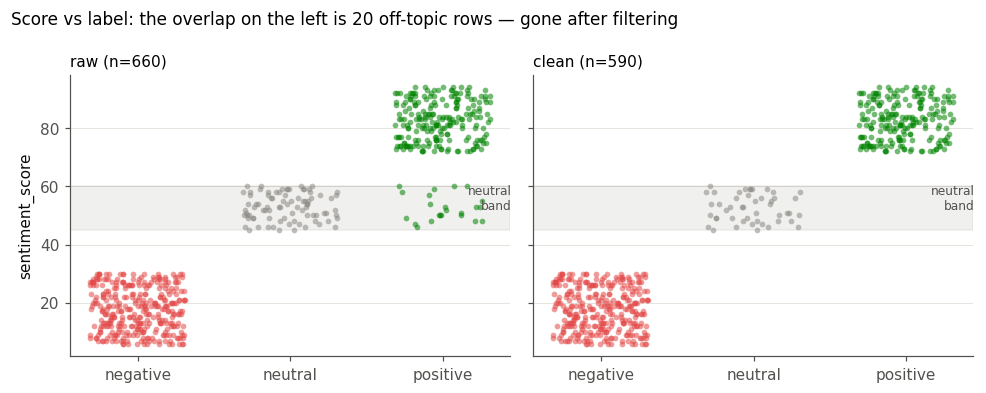

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
rng = pd.Series(range(999)).sample(frac=1, random_state=7)  # jitter source
for ax, (frame, title) in zip(axes, [(df, "raw (n=660)"), (clean, "clean (n=590)")]):
    for i, s in enumerate(SENT_ORDER):
        y = frame.loc[frame.sentiment == s, "sentiment_score"]
        jx = [i + (hash(v) % 100 - 50) / 160 for v in y.index]  # deterministic jitter
        ax.scatter(jx, y, s=14, color=SENT[s], alpha=0.55, linewidths=0, zorder=3)
    ax.axhspan(45, 60, color="#8a8983", alpha=0.12, zorder=1)
    ax.text(2.45, 52, "neutral\nband", fontsize=8, color=MUTED, ha="right")
    ax.set_xticks(range(3)); ax.set_xticklabels(SENT_ORDER)
    ax.set_title(title, loc="left", fontsize=10); style(ax)
axes[0].set_ylabel("sentiment_score")
fig.suptitle("Score vs label: the overlap on the left is 20 off-topic rows — gone after filtering", x=0.01, ha="left", fontsize=11)
plt.tight_layout(); plt.show()

**Judgment (a correction, honestly kept):** "label vs score disagree — pick one source of truth" was the *wrong diagnosis*. The overlap isn't an annotation problem, it's the **same relevance problem as Finding 1** wearing a different costume. One fix (the relevance filter) resolves both. The real label problem is elsewhere — §6.

## 5. Finding 4 — this feed is 68% templated text

Normalize the numbers and time-units out of each post and identical skeletons emerge. This matters for two reasons: (a) volume metrics count near-identical posts as independent voices, and (b) template families give us a lever to *audit the labels* — next section.

In [8]:
def normalize(text):
    t = text.lower()
    t = re.sub(r"\d+", "#", t)
    t = re.sub(r"\b(ghonta|din|min|minute|hour|day|sec|week)\b", "U", t)
    return re.sub(r"\s+", " ", t).strip()

df["template"] = df.text.map(normalize)
fam_sizes = df.groupby("template").size()
in_family = int(fam_sizes[fam_sizes >= 4].sum())
print(f"distinct templates: {len(fam_sizes)}")
print(f"rows in a template family of ≥4 members: {in_family}/{len(df)} ({in_family/len(df):.0%})")
print("\nbiggest families:")
for tmpl, n in fam_sizes.sort_values(ascending=False).head(5).items():
    print(f"  {n:>3}×  {tmpl[:80]}")

distinct templates: 245
rows in a template family of ≥4 members: 449/660 (68%)

biggest families:
   40×  # taka takapay theke katlo but receiver pay nai. # U dhore atke ache.
   29×  why is takapay charging # taka to cash out #? this is robbery.
   14×  takapay diye baba ke # taka pathalam, # U hoye gelo ekhono pending!
   11×  transaction fail holo tao # taka kete nilo, takapay er kono response nai.
   10×  takapay diye colleague ke # taka pathalam, # U hoye gelo ekhono pending!


## 6. Finding 5 — the big trap: 34 rows with sentiment flipped against their own text

**The detector:** inside each template family (≥4 members), take the majority sentiment as the family's true voice. Any member whose label disagrees with a ≥75% majority is a **suspect**. A small keyword union catches flips in families too small to vote. Fully deterministic — no model, no thresholds to tune, every flag explainable as *"this row disagrees with N near-identical siblings."*

Why not ML? spaCy has no Banglish sentiment capability, and 59% of this feed is code-mixed romanized Bangla. Against 68%-templated data, family-majority voting *is* the right instrument. (A code-mixed model like BanglaBERT is the honest "with another week" upgrade.)

In [9]:
suspects = {}

# layer 1: template-family majority vote
for tmpl, grp in df.groupby("template"):
    if len(grp) < 4:
        continue
    counts = grp.sentiment.value_counts()
    majority, majority_n = counts.index[0], counts.iloc[0]
    if majority_n / len(grp) >= 0.75:
        for rid, row in grp[grp.sentiment != majority].iterrows():
            suspects[row.id] = {"label": row.sentiment, "family_says": majority,
                                "family_n": len(grp), "via": "template", "text": row.text}

# layer 2: keyword union for small families (praise phrase + negative label, complaint phrase + positive label)
KEYWORD_RULES = [("darun offer", "negative", "positive"), ("atke ache", "positive", "negative")]
for phrase, wrong_label, true_label in KEYWORD_RULES:
    hits = df[df.text.str.lower().str.contains(phrase) & (df.sentiment == wrong_label)]
    for _, row in hits.iterrows():
        suspects.setdefault(row.id, {"label": row.sentiment, "family_says": true_label,
                                     "family_n": None, "via": f"keyword:{phrase}", "text": row.text})

sus = pd.DataFrame.from_dict(suspects, orient="index").sort_index()
print(f"SUSPECT LABELS: {len(sus)} rows ({len(sus)/len(df):.1%} of dataset)")
print("\nflip direction (label → what the text actually says):")
print(sus.groupby(["label", "family_says"]).size().to_string())
print("\nby topic:", df[df.id.isin(sus.index)].topic.value_counts().to_dict())

SUSPECT LABELS: 34 rows (5.2% of dataset)

flip direction (label → what the text actually says):
label     family_says
negative  positive       10
positive  negative       24

by topic: {'failed_transaction': 17, 'charges_fees': 5, 'recharge': 4, 'cashback_offer': 4, 'send_money': 2, 'customer_care': 1, 'login_otp': 1}


In [10]:
# read them yourself — every one is unambiguous
pd.set_option("display.max_colwidth", 95)
sus_view = sus.join(df.set_index("id")[["sentiment_score"]])
sus_view[["label", "sentiment_score", "family_says", "via", "text"]].sort_values("label", ascending=False)

,label,sentiment_score,family_says,via,text
1431,positive,79,negative,template,আমার একাউন্ট থেকে 1000 টাকা কেটে নিয়েছে কিন্তু Grameenphone রিচার্জ হয়নি। TakaPay এর কোনো...
1388,positive,83,negative,template,"TakaPay diye colleague ke 500 taka pathalam, 30 min hoye gelo ekhono pending!"
1623,positive,75,negative,template,"TakaPay diye amar friend ke 800 taka pathalam, 3 din hoye gelo ekhono pending!"
1617,positive,81,negative,template,"baba কে টাকা পাঠিয়েছি 2 ghonta আগে, এখনো পৌঁছায়নি। TakaPay কী করছে?"
1596,positive,72,negative,template,2000 taka TakaPay theke katlo but receiver pay nai. 2 ghonta dhore atke ache.
1587,positive,93,negative,template,2000 taka TakaPay theke katlo but receiver pay nai. 4 din dhore atke ache.
1569,positive,92,negative,template,1000 taka TakaPay theke katlo but receiver pay nai. 2 ghonta dhore atke ache.
1566,positive,94,negative,template,1500 taka TakaPay theke katlo but receiver pay nai. 1 week dhore atke ache.
1520,positive,83,negative,template,Why is TakaPay charging 20 taka to cash out 300? This is robbery.
1481,positive,91,negative,template,800 taka TakaPay theke katlo but receiver pay nai. 2 din dhore atke ache.


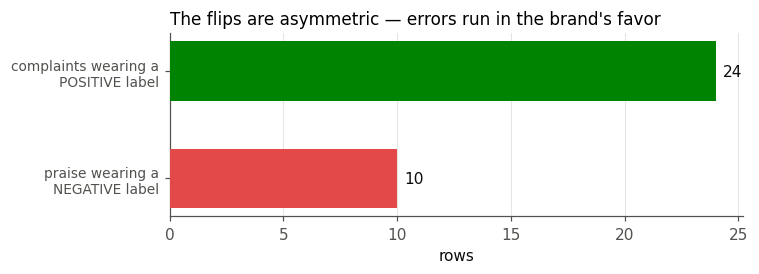

net effect: 24 hidden complaints vs 10 hidden praise → the feed looks better than reality


In [11]:
flips = sus.groupby(["label", "family_says"]).size()
comp_to_pos = int(flips.get(("positive", "negative"), 0))   # complaints labeled positive
praise_to_neg = int(flips.get(("negative", "positive"), 0)) # praise labeled negative

fig, ax = plt.subplots(figsize=(7, 2.6))
bars = ax.barh([1, 0], [comp_to_pos, praise_to_neg], height=0.55,
               color=[SENT["positive"], SENT["negative"]], zorder=3)
ax.set_yticks([1, 0])
ax.set_yticklabels(["complaints wearing a\nPOSITIVE label", "praise wearing a\nNEGATIVE label"], fontsize=9)
for b, v in zip(bars, [comp_to_pos, praise_to_neg]):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2, str(v), va="center", color=INK)
ax.set_xlabel("rows"); style(ax, xgrid=True, ygrid=False)
ax.set_title("The flips are asymmetric — errors run in the brand's favor", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
print(f"net effect: {comp_to_pos} hidden complaints vs {praise_to_neg} hidden praise → the feed looks better than reality")

**Judgment — the key one in the whole analysis:** on these rows the label and the score *agree with each other* (a "positive 93" complaint) — so "trust the score over the label" fails. **Only the text is ground truth.** Note what a "positive mentions" filter would do on a real dashboard: surface *"money deducted, stuck for 4 days"* as a happy customer.

**Ruling: flag, don't fix.** The tool keeps the provided labels in every headline number, flags the 34 suspects visibly, and reports what correcting them would do (next section). Silently re-labeling data because a heuristic disagrees is how a *different* trust problem starts.

## 7. Finding 6 — the trust arc: what the dashboard says depends on what you let reach it

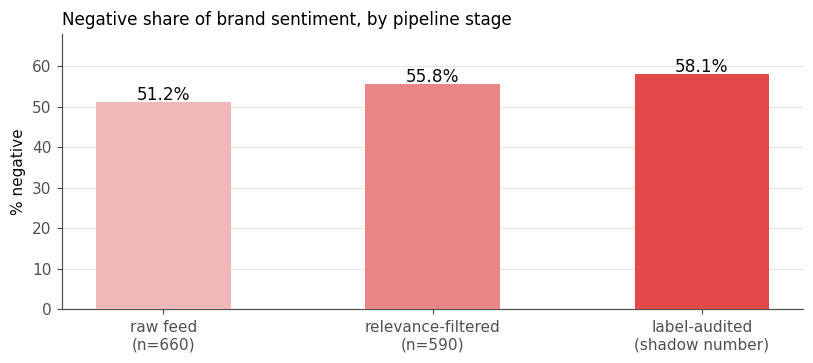

raw 51.2%  →  clean 55.8%  →  audited 58.1%   (understatement: 6.9 pts)


In [12]:
raw_neg = (df.sentiment == "negative").mean() * 100
clean_neg = (clean.sentiment == "negative").mean() * 100

corrected = clean.merge(sus[["family_says"]], left_on="id", right_index=True, how="left")
corrected["audited"] = corrected.family_says.fillna(corrected.sentiment)
audited_neg = (corrected.audited == "negative").mean() * 100

stages = ["raw feed\n(n=660)", "relevance-filtered\n(n=590)", "label-audited\n(shadow number)"]
vals = [raw_neg, clean_neg, audited_neg]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(stages, vals, width=0.5, color=["#f0b8b8", "#e88585", SENT["negative"]], zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11, color=INK)
ax.set_ylim(0, 68); ax.set_ylabel("% negative"); style(ax)
ax.set_title("Negative share of brand sentiment, by pipeline stage", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
print(f"raw {raw_neg:.1f}%  →  clean {clean_neg:.1f}%  →  audited {audited_neg:.1f}%   (understatement: {audited_neg-raw_neg:.1f} pts)")

**Judgment:** each stage is a data-trust decision, not a math trick: drop what isn't about the brand (+4.6 pts), then audit labels against text (+2 more). The dashboard shows the clean number as its headline (labels as provided — flag-don't-fix) and the audited ~58% as a clearly-marked *shadow number* in the trust panel.

## 8. Finding 7 — one topic is the story: `failed_transaction`

(All topic metrics from here on use the 590 relevant mentions.)

sentiment           total  pct_negative
topic                                  
failed_transaction    220          89.5
competitor             72         100.0
cashback_offer         63           6.3
recharge               50           8.0
send_money             50           8.0
charges_fees           30          83.3
agent_network          26           0.0
bill_payment           24           4.2
feature_query          19           0.0
customer_care          13          30.8
login_otp              10          90.0
app_crash               9          88.9
app_experience          2          50.0
product_news            2           0.0

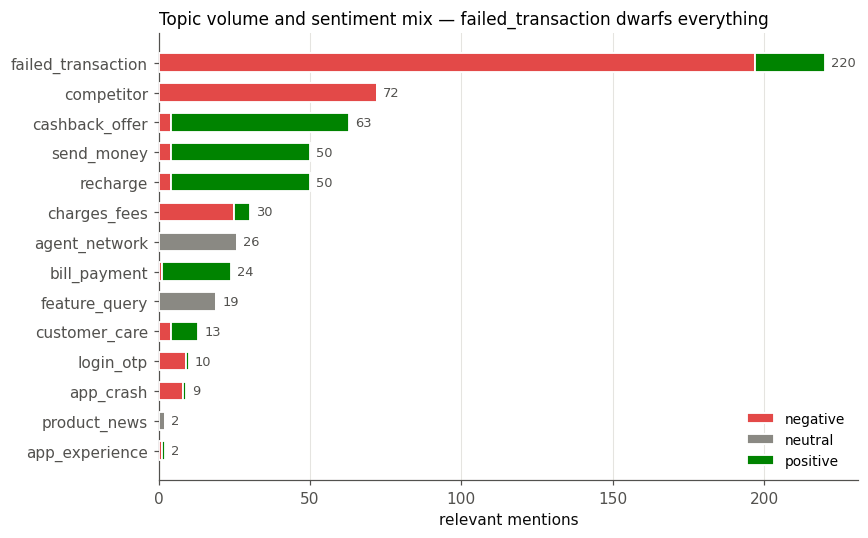

In [13]:
topic_sent = (clean.groupby(["topic", "sentiment"]).size().unstack(fill_value=0)
              .reindex(columns=SENT_ORDER).assign(total=lambda d: d.sum(axis=1))
              .sort_values("total"))
topic_sent["pct_negative"] = (topic_sent.negative / topic_sent.total * 100).round(1)
print(topic_sent.sort_values("total", ascending=False)[["total", "pct_negative"]].to_string())

fig, ax = plt.subplots(figsize=(8, 5))
left = pd.Series(0.0, index=topic_sent.index)
for s in SENT_ORDER:
    ax.barh(topic_sent.index, topic_sent[s], left=left, color=SENT[s], height=0.62,
            zorder=3, label=s, edgecolor="white", linewidth=1.2)
    left += topic_sent[s]
for t, row in topic_sent.iterrows():
    ax.text(row.total + 2, t, f"{int(row.total)}", va="center", fontsize=8.5, color=MUTED)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_xlabel("relevant mentions"); style(ax, xgrid=True, ygrid=False)
ax.set_title("Topic volume and sentiment mix — failed_transaction dwarfs everything", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

**Judgment:** `failed_transaction` alone is **220 posts — 37% of relevant volume — at ~90% negative**. Everything else negative is money-friction too: fees, OTP/login, crashes. Meanwhile `agent_network` (100% neutral) and `feature_query` are *informational* — "where is an agent", "how do I X" — not complaints; their neutrality is genuine, not a labeling error. A brand manager doesn't need "51% negative"; they need **"failed transactions are the fire."**

## 9. Finding 8 — the product call: "fix this first"

Volume × %negative sounds like a formula but arithmetically it *is* the count of negative mentions. Shown honestly as such, over **brand-operational topics only** — `competitor` is excluded because "people prefer NgoodPay" is competitive pressure, not an ops ticket. *Separate what you fix from what you fight.*

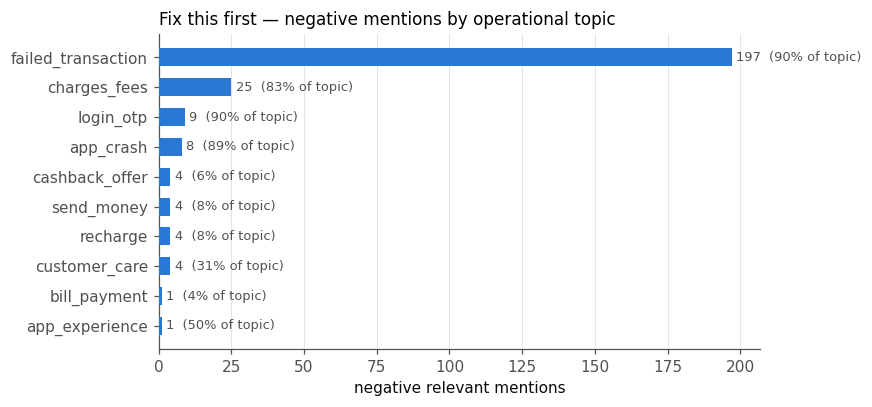

competitor topic (excluded here): 72 negative mentions → routed to the competitor view (§10)


In [14]:
ops = topic_sent.drop(index=[t for t in ("competitor",) if t in topic_sent.index])
rank = ops[ops.negative > 0].sort_values("negative")

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(rank.index, rank.negative, color=BLUE, height=0.6, zorder=3)
for b, (t, row) in zip(bars, rank.iterrows()):
    ax.text(row.negative + 1.5, b.get_y() + b.get_height()/2,
            f"{int(row.negative)}  ({row.pct_negative:.0f}% of topic)", va="center", fontsize=8.5, color=MUTED)
ax.set_xlabel("negative relevant mentions"); style(ax, xgrid=True, ygrid=False)
ax.set_title("Fix this first — negative mentions by operational topic", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

print(f"competitor topic (excluded here): {int(topic_sent.loc['competitor', 'negative'])} negative mentions → routed to the competitor view (§10)")

## 10. Finding 9 — NgoodPay: a clean, ready-made competitive signal

Two distinct signals, deliberately not blended:
- **72 comparison posts** that name TakaPay — 100% negative, all unfavorable comparisons. These stay in brand sentiment *and* feed the competitor view.
- **9 competitor-only promo posts** (§2) — competitive activity, excluded from brand sentiment.

comparison posts (name TakaPay): 72 — sentiment: {'negative': 72}
competitor-only promo posts:      9


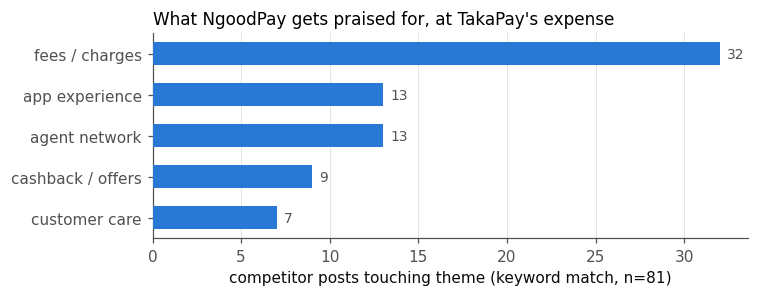


sample comparisons:
  • bhai bollo NgoodPay er customer care TakaPay er cheye onek valo.
  • NgoodPay er cash out charge 500 e onek kom, tai TakaPay chere switch korlam.
  • colleague bollo NgoodPay er customer care TakaPay er cheye onek valo.


In [15]:
comp = df[df.topic == "competitor"]
print(f"comparison posts (name TakaPay): {int(comp.mentions_brand.sum())} — sentiment: {comp[comp.mentions_brand].sentiment.value_counts().to_dict()}")
print(f"competitor-only promo posts:      {int((~comp.mentions_brand).sum())}")

themes = {"fees / charges": ["fee", "charge", "kom"], "agent network": ["agent"],
          "customer care": ["care", "customer"], "cashback / offers": ["cashback", "offer"],
          "app experience": ["app", "smooth"]}
theme_counts = {name: int(comp.text.str.lower().apply(lambda t: any(k in t for k in kws)).sum())
                for name, kws in themes.items()}
ts = pd.Series(theme_counts).sort_values()

fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(ts.index, ts.values, color=BLUE, height=0.55, zorder=3)
for b, v in zip(bars, ts.values):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, str(v), va="center", fontsize=9, color=MUTED)
ax.set_xlabel("competitor posts touching theme (keyword match, n=81)")
style(ax, xgrid=True, ygrid=False)
ax.set_title("What NgoodPay gets praised for, at TakaPay's expense", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

print("\nsample comparisons:")
for t in comp[comp.mentions_brand].text.sample(3, random_state=3):
    print("  •", t)

**Judgment:** the recurring blows are **lower cash-out fees** (the #1 theme by far — and note `charges_fees` is also TakaPay's 4th-largest internal complaint, so the fee story attacks from both sides), denser agent coverage in named neighborhoods, better care, bigger promos. This is the brief's suggested stretch goal, essentially pre-assembled by the data.

## 11. Finding 10 — the language "insight" that isn't: a total confound

Naive cut: Banglish (bn-en) posts are 65.9% negative, English 26.1% — *"Banglish users are angrier!"* Look at what each language actually talks about:

In [16]:
lang_neg = clean.groupby("language").apply(lambda g: (g.sentiment == "negative").mean() * 100, include_groups=False).round(1)
print("naive %negative by language:", lang_neg.to_dict())

cross = pd.crosstab(clean.language, clean.topic)
print("\nlanguage × topic (clean):")
print(cross.to_string())

en_topics = set(cross.columns[cross.loc["en"] > 0]) if "en" in cross.index else set()
bnen_topics = set(cross.columns[cross.loc["bn-en"] > 0])
print(f"\ntopics shared by en and bn-en: {en_topics & bnen_topics or 'NONE — zero overlap'}")

ft = clean[clean.topic == "failed_transaction"]
print("\nwithin failed_transaction (the one topic two languages share):")
print(ft.groupby("language").apply(lambda g: f"n={len(g)}, {(g.sentiment=='negative').mean():.1%} negative", include_groups=False).to_string())

naive %negative by language:

 {'bn': 56.8, 'bn-en': 65.9, 'en': 26.1}

language × topic (clean):
topic     agent_network  app_crash  app_experience  bill_payment  cashback_offer  charges_fees  competitor  customer_care  failed_transaction  feature_query  login_otp  product_news  recharge  send_money
language                                                                                                                                                                                                   
bn                    0          0               0             0               0             0           0              0                  95             10          0             0         0          50
bn-en                26          9               2             0              63             0          72             13                 125              0         10             0         0           0
en                    0          0               0            24               0            30           0          

**Judgment:** English and Banglish posts share **zero topics** — English posts are all recharge/bills/fees templates; every competitor post and most failed-transaction posts are Banglish. The language–sentiment comparison is confounded *by construction*; and within `failed_transaction` (the one cross-language topic), bn and bn-en negativity are near-identical (88.4% vs 90.4%). **The real language finding is coverage, not anger:** 59% of the feed is code-mixed — a pipeline that only handles English or pure Bangla misreads the majority of posts, including 25 of the 34 flipped labels (18 code-mixed + 7 Bangla script — only the English "robbery" family would survive an English-only model).

## 12. Finding 11 — platform explains volume, not sentiment

              n  pct_neg
platform                
Facebook    198     57.6
Reddit       75     62.7
News/Media   71     47.9
Instagram    68     47.1
YouTube      65     49.2
Twitter      57     57.9
TikTok       56     66.1


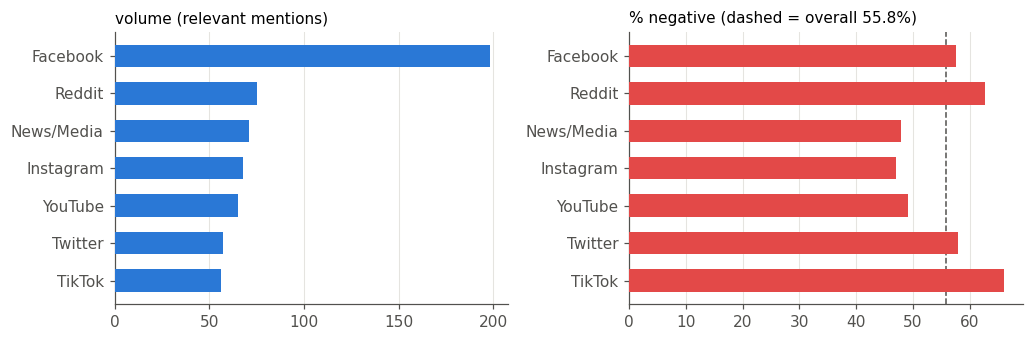

In [17]:
plat = (clean.groupby("platform").agg(n=("id", "count"),
        pct_neg=("sentiment", lambda s: (s == "negative").mean() * 100))
        .sort_values("n", ascending=False).round(1))
print(plat.to_string())

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
p = plat.sort_values("n")
axes[0].barh(p.index, p.n, color=BLUE, height=0.6, zorder=3)
axes[0].set_title("volume (relevant mentions)", loc="left", fontsize=10)
axes[1].barh(p.index, p.pct_neg, color=SENT["negative"], height=0.6, zorder=3)
axes[1].axvline(clean.sentiment.eq("negative").mean()*100, color=MUTED, lw=1, ls="--")
axes[1].set_title("% negative (dashed = overall 55.8%)", loc="left", fontsize=10)
for ax in axes:
    style(ax, xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

**Judgment:** Facebook is a third of the feed — that's *where to watch*. But negativity sits in a 47–66% band everywhere: platform tells you nothing about *why* sentiment is bad. Topic does. (Reddit's 0% neutral is a small-sample artifact, n=75.)

## 13. Finding 12 — 10 byte-identical posts from *different* authors on *different* platforms

In [18]:
dup_groups = df[df.duplicated("text", keep=False)].sort_values("text")
print(f"exact-duplicate texts: {dup_groups.text.nunique()} distinct texts, {len(dup_groups)} rows\n")
print(dup_groups[["id", "platform", "author", "text"]].head(6).to_string(index=False, max_colwidth=70))

exact-duplicate texts: 10 distinct texts, 20 rows

  id  platform   author                                                                   text
1653  Facebook   Rima24 5000 taka TakaPay theke katlo but receiver pay nai. 2 din dhore atk...
1527  Facebook  Rasel17 5000 taka TakaPay theke katlo but receiver pay nai. 2 din dhore atk...
1660 Instagram Nusrat67 Instant Airtel recharge on TakaPay, 2500 taka, done before I finish...
1237 Instagram  Rakib41 Instant Airtel recharge on TakaPay, 2500 taka, done before I finish...
1573   YouTube  Rasel52 Instant Robi recharge on TakaPay, 2500 taka, done before I finished...
1656   YouTube  Rasel19 Instant Robi recharge on TakaPay, 2500 taka, done before I finished...


**Judgment:** same words, different account, different platform — in a real feed that's the signature of coordinated/bot posting; in this one, of templated generation. **Ruling: keep them in metrics, report them in the trust panel.** The tool's only silent exclusion is relevance — every other anomaly is flagged, not deleted (~3% of rows; no metric moves meaningfully either way).

## 14. Finding 13 — the engagement columns are noise (checked so they can be dismissed)

Two columns this analysis conspicuously hasn't used: `reactions` and `comments`. That's deliberate:

           mean_reactions  mean_comments  mean_engagement
sentiment                                                
negative            236.3           59.8            296.0
neutral             247.4           54.8            302.2
positive            241.7           59.8            301.6


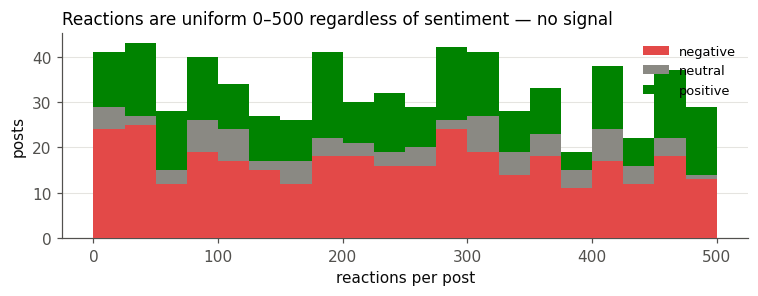

In [19]:
eng = df.assign(engagement=df.reactions + df.comments)
print(eng.groupby("sentiment").agg(mean_reactions=("reactions", "mean"),
                                   mean_comments=("comments", "mean"),
                                   mean_engagement=("engagement", "mean")).round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist([eng.loc[eng.sentiment == s, "reactions"] for s in SENT_ORDER],
        bins=20, stacked=True, color=[SENT[s] for s in SENT_ORDER], label=SENT_ORDER, zorder=3)
ax.legend(frameon=False, fontsize=8.5)
ax.set_xlabel("reactions per post"); ax.set_ylabel("posts"); style(ax)
ax.set_title("Reactions are uniform 0–500 regardless of sentiment — no signal", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

**Judgment:** flat uniform draw, near-identical means across sentiments, no topic pattern. Any engagement-weighted metric would launder randomness into the dashboard. Checked, documented, excluded.

## 15. Finding 14 — volume is flat: there is no time-series story

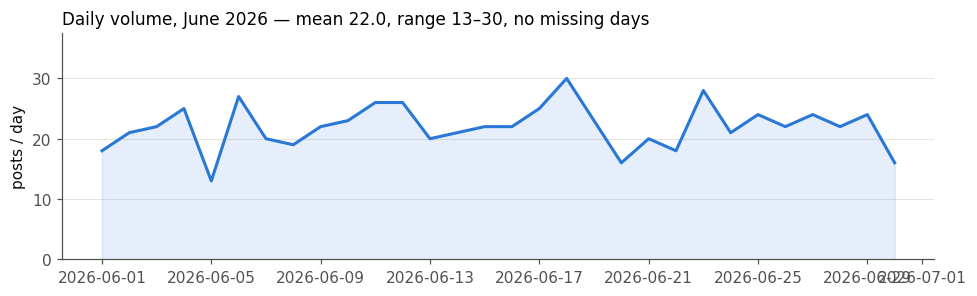

In [20]:
daily = df.set_index("timestamp").resample("D").size()
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(daily.index, daily.values, color=BLUE, lw=2, zorder=3)
ax.fill_between(daily.index, daily.values, color=BLUE, alpha=0.12, zorder=2)
ax.set_ylim(0, daily.max() * 1.25); ax.set_ylabel("posts / day"); style(ax)
ax.set_title(f"Daily volume, June 2026 — mean {daily.mean():.1f}, range {daily.min()}–{daily.max()}, no missing days", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

**Judgment:** one month, no spikes, no trend, no crisis-detection story. Don't force a time-series narrative the data can't support — a date filter is fine; a trend chart pretending to show momentum is not.

## 16. Where this lands — findings → decisions → build

### The two-trap structure
1. **Relevance trap** — 70/660 rows aren't about the brand; they skew positive/neutral, flattening the negativity signal.
2. **Label trap** — 34 rows have label+score flipped against their text (24 hidden complaints vs 10 hidden praise), net direction again flattering the brand.

Both traps push the same way. Raw feed: **51.2%** negative. Truth: **~58%**. That 7-point gap *is* the reason data trust is the product's first feature.

### Locked decisions (each defended above)
| # | Decision | Ruling |
|---|---|---|
| 1 | Sentiment source of truth | **Flag, don't fix** — provided labels everywhere, suspects flagged, shadow number in trust panel |
| 2 | 9 competitor-only posts | Out of brand sentiment; separate competitive-intelligence signal |
| 3 | Duplicate pairs | Kept in metrics, reported in trust panel |
| 4 | Suspect detection | Deterministic template-majority + keyword union; ML deferred (BanglaBERT, next week) |
| 5 | Product call | "Fix this first" ranking — negative mentions by ops topic; `failed_transaction` #1 |
| 6 | Competitor topic | Excluded from ops ranking — *separate what you fix from what you fight* |
| 7 | Language view | Coverage framing (59% code-mixed), confound stated on-chart |
| 8 | Engagement | Excluded everywhere, documented as noise |

### What the build consumes
A Python pipeline reproduces §2–§15 and emits one `metrics.json` (headline stats, trust-panel numbers, topic/priority/competitor/language/platform aggregates, per-mention rows with `is_relevant` / `is_suspect` / `is_duplicate` flags) → static Next.js dashboard on Vercel. No server state, nothing to fall over mid-review.